# 04 — Probability of Default & Risk Segmentation

## Objective

This notebook converts the selected credit-risk model's prediction
probabilities into model-estimated Probability of Default (PD) and
project-level risk categories.

The notebook will:

- load the saved XGBoost pipeline
- generate default probabilities
- assess probability calibration
- define Low, Medium, and High risk tiers
- validate whether the tiers separate observed default risk
- create a customer-level risk output for downstream analysis

The risk-tier thresholds are project-defined decision rules and are not
intended to represent universal banking or regulatory thresholds.

In [17]:
import pandas as pd
import numpy as np
import joblib
import json

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

## 1. Load Saved Model

The trained XGBoost pipeline is loaded from the model artifact created
in `03_credit_risk_modeling.ipynb`.

Loading the saved pipeline ensures that the exact preprocessing and
trained model used during final evaluation are reused here.

In [18]:
model_path = Path("../models/credit_risk_xgboost_pipeline.joblib")
config_path = Path("../models/risk_config.json")

model = joblib.load(model_path)

with open(config_path, "r") as f:
    risk_config = json.load(f)

print("Model loaded successfully.")
print("Risk configuration:")
print(risk_config)

Model loaded successfully.
Risk configuration:
{'model_name': 'XGBoost', 'classification_threshold': 0.30000000000000004, 'risk_tiers': {'low': {'min_pd': 0.0, 'max_pd': 0.1}, 'medium': {'min_pd': 0.1, 'max_pd': 0.3}, 'high': {'min_pd': 0.3, 'max_pd': 1.0}}, 'random_state': 42, 'target': 'default'}


## 2. Load Model-Ready Data

The feature-engineered dataset is loaded independently of the modeling
notebook. This keeps the PD analysis reproducible and prevents it from
depending on variables remaining in notebook memory.

In [19]:
df = pd.read_csv("../data/processed/credit_risk_features.csv")

print("Dataset shape:", df.shape)

Dataset shape: (29965, 34)


## 3. Recreate Evaluation Split

The same random state and stratified split used during model evaluation
are reproduced so that the test observations correspond to the final
test set used in `03_credit_risk_modeling.ipynb`.

In [20]:
X = df.drop(columns="default")
y = df["default"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("Test set:", X_test.shape)
print("Test default rate:", y_test.mean())

Test set: (5993, 33)
Test default rate: 0.22125813449023862


## 4. Generate Model-Estimated Probability of Default

The saved XGBoost pipeline produces a probability for each test
observation representing the model's estimated likelihood of default.

These probabilities are treated as model-estimated Probability of
Default (PD) for this project.

The PD is kept separate from the binary classification threshold:
the probability provides a continuous risk measure, while the
threshold is used only when a binary decision is required.

In [21]:
xgb_test_proba = model.predict_proba(X_test)[:, 1]

print("Number of PD predictions:", len(xgb_test_proba))
print("Minimum PD:", xgb_test_proba.min())
print("Maximum PD:", xgb_test_proba.max())
print("Mean PD:", xgb_test_proba.mean())

Number of PD predictions: 5993
Minimum PD: 0.0070680305
Maximum PD: 0.9236592
Mean PD: 0.21816823


In [22]:
# Inspecting the distribution.
pd.Series(xgb_test_proba).describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    5993.000000
mean        0.218168
std         0.208409
min         0.007068
25%         0.075075
50%         0.138554
75%         0.274771
90%         0.568402
95%         0.733545
99%         0.841633
max         0.923659
dtype: float64

## 5. Probability Calibration

A predicted probability is more useful as a PD estimate when predicted
probabilities correspond reasonably well to observed default frequencies.

Calibration is assessed using:

- Brier score
- reliability/calibration curve

A perfectly calibrated model would have an observed default rate
approximately equal to the predicted probability within each probability
group.

In [23]:
raw_test_brier = brier_score_loss(
    y_test,
    xgb_test_proba
)

print(f"Raw XGBoost test Brier score: {raw_test_brier:.4f}")

Raw XGBoost test Brier score: 0.1367


In [24]:
# Calibration curve.
prob_true, prob_pred = calibration_curve(
    y_test,
    xgb_test_proba,
    n_bins=10,
    strategy="quantile"
)

calibration_df = pd.DataFrame({
    "mean_predicted_probability": prob_pred,
    "observed_default_rate": prob_true
})

calibration_df

,mean_predicted_probability,observed_default_rate
0,0.030827,0.045000
1,0.054760,0.070117
2,0.075396,0.100167
3,0.097808,0.120200
4,0.123395,0.155000
5,0.156049,0.146912
6,0.202118,0.200334
7,0.276038,0.273790
8,0.438412,0.410684
9,0.726501,0.690000


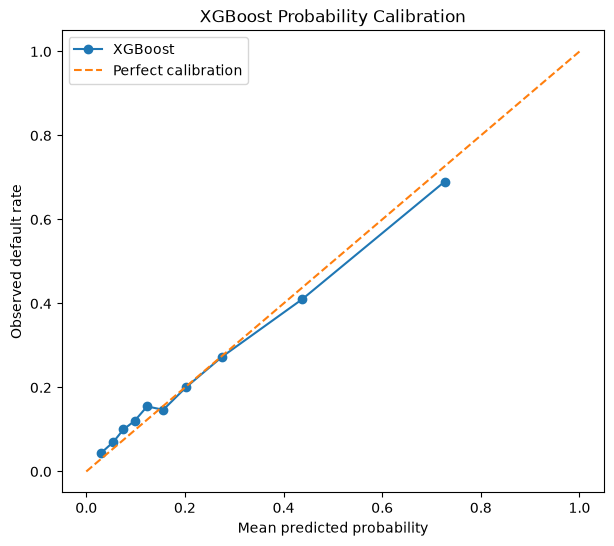

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.title("XGBoost Probability Calibration")
plt.legend()
plt.show()

## 6. Risk-Tier Segmentation

For dashboard and risk-analysis purposes, the continuous PD is mapped
to three project-defined risk tiers:

- Low Risk: PD < 10%
- Medium Risk: 10% ≤ PD < 30%
- High Risk: PD ≥ 30%

These thresholds are project-level decision rules. They are not claimed
to represent universal banking or regulatory risk thresholds.

In [26]:
risk_bins = [
    -np.inf,
    risk_config["risk_tiers"]["low"]["max_pd"],
    risk_config["risk_tiers"]["medium"]["max_pd"],
    np.inf
]

risk_labels = ["Low", "Medium", "High"]

test_pd = pd.DataFrame({
    "pd": xgb_test_proba,
    "actual_default": y_test.reset_index(drop=True)
})

test_pd["risk_tier"] = pd.cut(
    test_pd["pd"],
    bins=risk_bins,
    labels=risk_labels,
    right=False
)

test_pd.head()

,pd,actual_default,risk_tier
0,0.102868,0,Medium
1,0.077565,0,Low
2,0.155555,0,Medium
3,0.165420,0,Medium
4,0.011902,0,Low


In [27]:
# Validate the tiers.
risk_summary = (
    test_pd
    .groupby("risk_tier", observed=False)
    .agg(
        customers=("actual_default", "size"),
        average_pd=("pd", "mean"),
        observed_default_rate=("actual_default", "mean")
    )
)

risk_summary["average_pd"] *= 100
risk_summary["observed_default_rate"] *= 100

risk_summary.round(2)

,customers,average_pd,observed_default_rate
risk_tier,,,
Low,2149,6.000000,7.63
Medium,2497,17.350000,18.10
High,1347,55.330002,52.71


In [28]:
test_pd["risk_tier"].value_counts().sort_index()

risk_tier
Low       2149
Medium    2497
High      1347
Name: count, dtype: int64

### Risk-Tier Interpretation

The risk tiers show a clear monotonic increase in observed default rate:

- Low Risk: 7.63%
- Medium Risk: 18.10%
- High Risk: 52.71%

The average predicted PD also increases consistently across the tiers.

This indicates that the project-defined PD bands provide meaningful
risk stratification rather than simply assigning arbitrary labels.

The Low / Medium / High boundaries are project-level segmentation rules
and should not be interpreted as universal banking or regulatory
thresholds.

## 7. Customer-Level Risk Output

The model-estimated PD and risk tier are combined with the original test
observation index and actual outcome.

The actual outcome is retained for model evaluation, while the PD and
risk tier represent the information that would be available for a
future customer-risk application.

In [29]:
customer_risk_output = pd.DataFrame({
    "customer_index": X_test.index,
    "pd": xgb_test_proba,
    "risk_tier": pd.cut(
        xgb_test_proba,
        bins=risk_bins,
        labels=risk_labels,
        right=False
    ),
    "actual_default": y_test.values
})

customer_risk_output.head(10)

,customer_index,pd,risk_tier,actual_default
0,8681,0.102868,Medium,0
1,24179,0.077565,Low,0
2,27755,0.155555,Medium,0
3,14938,0.165420,Medium,0
4,1486,0.011902,Low,0
5,1139,0.045888,Low,0
6,26456,0.131334,Medium,0
7,27719,0.087807,Low,0
8,1071,0.088003,Low,1
9,6988,0.054361,Low,0


In [30]:
customer_risk_output.shape

(5993, 4)

In [31]:
customer_risk_output["risk_tier"].value_counts().sort_index()

risk_tier
Low       2149
Medium    2497
High      1347
Name: count, dtype: int64

## 8. Save Risk Output

The customer-level risk output is saved for downstream analysis and
will later provide an input for the dashboard and monitoring components.

In [32]:
risk_output_path = "../data/processed/customer_risk_output.csv"

customer_risk_output.to_csv(
    risk_output_path,
    index=False
)

print(f"Saved to: {risk_output_path}")

Saved to: ../data/processed/customer_risk_output.csv


## 9. PD & Risk Segmentation Summary

The selected XGBoost model produces model-estimated Probability of
Default (PD) for each customer.

The raw probability estimates achieved a test Brier score of 0.1367 and
showed reasonable agreement between predicted and observed default
frequencies across probability groups.

Sigmoid calibration was evaluated separately but did not improve the
Brier score, so the raw XGBoost probabilities are retained.

The project defines three risk tiers:

- Low Risk: PD < 10%
- Medium Risk: 10% ≤ PD < 30%
- High Risk: PD ≥ 30%

The observed default rates increase substantially across these tiers,
supporting their use as an initial project-level risk segmentation
policy.

The resulting customer-level PD and risk tier output is saved for use
in later explainability, monitoring, and dashboard components.